In [ ]:
# SQL Analysis
Re-implementing key business queries using SQL via SQLite.
Demonstrates ability to answer the same questions in both pandas and SQL.

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# Load and clean data
df = pd.read_csv('../data/online_retail.csv', encoding='latin-1')
df = df.dropna(subset=['CustomerID'])
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Revenue'] = df['Quantity'] * df['UnitPrice']
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M').astype(str)
df['Hour'] = df['InvoiceDate'].dt.hour
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()

# Create SQLite database
conn = sqlite3.connect('../data/retail.db')
df.to_sql('sales', conn, if_exists='replace', index=False)

print("Database created successfully!")
print(f"Rows loaded: {pd.read_sql('SELECT COUNT(*) as count FROM sales', conn).iloc[0,0]:,}")
print(f"\nTable columns:")
schema = pd.read_sql("PRAGMA table_info(sales)", conn)
print(schema[['name','type']].to_string(index=False))query_monthly = """
SELECT
    YearMonth,
    ROUND(SUM(Revenue), 2)      AS Total_Revenue,
    COUNT(DISTINCT InvoiceNo)   AS Total_Orders,
    COUNT(DISTINCT CustomerID)  AS Unique_Customers
FROM sales
GROUP BY YearMonth
ORDER BY YearMonth
"""

monthly = pd.read_sql(query_monthly, conn)
print("Monthly revenue (SQL):")
print(monthly.to_string(index=False))

Database created successfully!
Rows loaded: 397,884

Table columns:
       name      type
  InvoiceNo      TEXT
  StockCode      TEXT
Description      TEXT
   Quantity   INTEGER
InvoiceDate TIMESTAMP
  UnitPrice      REAL
 CustomerID      REAL
    Country      TEXT
    Revenue      REAL
  YearMonth      TEXT
       Hour   INTEGER
  DayOfWeek      TEXT


In [2]:
query_monthly = """
SELECT
    YearMonth,
    ROUND(SUM(Revenue), 2)      AS Total_Revenue,
    COUNT(DISTINCT InvoiceNo)   AS Total_Orders,
    COUNT(DISTINCT CustomerID)  AS Unique_Customers
FROM sales
GROUP BY YearMonth
ORDER BY YearMonth
"""

monthly = pd.read_sql(query_monthly, conn)
print("Monthly revenue (SQL):")
print(monthly.to_string(index=False))

Monthly revenue (SQL):
YearMonth  Total_Revenue  Total_Orders  Unique_Customers
  2010-12      572713.89          1400               885
  2011-01      569445.04           987               741
  2011-02      447137.35           997               758
  2011-03      595500.76          1321               974
  2011-04      469200.36          1149               856
  2011-05      678594.56          1555              1056
  2011-06      661213.69          1393               991
  2011-07      600091.01          1331               949
  2011-08      645343.90          1280               935
  2011-09      952838.38          1755              1266
  2011-10     1039318.79          1929              1364
  2011-11     1161817.38          2657              1664
  2011-12      518192.79           778               615


In [3]:
query_top_customers = """
SELECT
    CAST(CustomerID AS INTEGER)     AS CustomerID,
    Country,
    ROUND(SUM(Revenue), 2)          AS Total_Revenue,
    COUNT(DISTINCT InvoiceNo)       AS Total_Orders,
    ROUND(SUM(Revenue) /
          COUNT(DISTINCT InvoiceNo), 2) AS Avg_Order_Value
FROM sales
GROUP BY CustomerID, Country
ORDER BY Total_Revenue DESC
LIMIT 10
"""

top_customers = pd.read_sql(query_top_customers, conn)
print("Top 10 customers by revenue (SQL):")
print(top_customers.to_string(index=False))

Top 10 customers by revenue (SQL):
 CustomerID        Country  Total_Revenue  Total_Orders  Avg_Order_Value
      14646    Netherlands      280206.02            73          3838.44
      18102 United Kingdom      259657.30            60          4327.62
      17450 United Kingdom      194550.79            46          4229.36
      16446 United Kingdom      168472.50             2         84236.25
      14911           EIRE      143825.06           201           715.55
      12415      Australia      124914.53            21          5948.31
      14156           EIRE      117379.63            55          2134.18
      17511 United Kingdom       91062.38            31          2937.50
      16029 United Kingdom       81024.84            63          1286.11
      12346 United Kingdom       77183.60             1         77183.60


In [4]:
query_countries = """
SELECT
    Country,
    ROUND(SUM(Revenue), 2)        AS Total_Revenue,
    COUNT(DISTINCT InvoiceNo)     AS Total_Orders,
    COUNT(DISTINCT CustomerID)    AS Unique_Customers,
    ROUND(SUM(Revenue) /
          COUNT(DISTINCT InvoiceNo), 2) AS Avg_Order_Value
FROM sales
GROUP BY Country
ORDER BY Total_Revenue DESC
LIMIT 15
"""

countries = pd.read_sql(query_countries, conn)
print("Revenue by country (SQL):")
print(countries.to_string(index=False))

Revenue by country (SQL):
       Country  Total_Revenue  Total_Orders  Unique_Customers  Avg_Order_Value
United Kingdom     7308391.55         16646              3920           439.05
   Netherlands      285446.34            94                 9          3036.66
          EIRE      265545.90           260                 3          1021.33
       Germany      228867.14           457                94           500.80
        France      209024.05           389                87           537.34
     Australia      138521.31            57                 9          2430.20
         Spain       61577.11            90                30           684.19
   Switzerland       56443.95            51                21          1106.74
       Belgium       41196.34            98                25           420.37
        Sweden       38378.33            36                 8          1066.06
         Japan       37416.37            19                 8          1969.28
        Norway       36165

In [5]:
query_aov = """
SELECT
    YearMonth,
    ROUND(SUM(Revenue) /
          COUNT(DISTINCT InvoiceNo), 2) AS Avg_Order_Value,
    COUNT(DISTINCT InvoiceNo)           AS Total_Orders,
    ROUND(SUM(Revenue), 2)              AS Total_Revenue
FROM sales
GROUP BY YearMonth
ORDER BY YearMonth
"""

aov = pd.read_sql(query_aov, conn)
print("Average order value by month (SQL):")
print(aov.to_string(index=False))

Average order value by month (SQL):
YearMonth  Avg_Order_Value  Total_Orders  Total_Revenue
  2010-12           409.08          1400      572713.89
  2011-01           576.95           987      569445.04
  2011-02           448.48           997      447137.35
  2011-03           450.80          1321      595500.76
  2011-04           408.36          1149      469200.36
  2011-05           436.40          1555      678594.56
  2011-06           474.67          1393      661213.69
  2011-07           450.86          1331      600091.01
  2011-08           504.17          1280      645343.90
  2011-09           542.93          1755      952838.38
  2011-10           538.79          1929     1039318.79
  2011-11           437.27          2657     1161817.38
  2011-12           666.06           778      518192.79


In [6]:
query_hours = """
SELECT
    Hour,
    COUNT(DISTINCT InvoiceNo)   AS Total_Orders,
    ROUND(SUM(Revenue), 2)      AS Total_Revenue,
    COUNT(DISTINCT CustomerID)  AS Unique_Customers
FROM sales
GROUP BY Hour
ORDER BY Hour
"""

hours = pd.read_sql(query_hours, conn)
print("Orders by hour of day (SQL):")
print(hours.to_string(index=False))

Orders by hour of day (SQL):
 Hour  Total_Orders  Total_Revenue  Unique_Customers
    6             1           4.25                 1
    7            29       31059.21                28
    8           555      282115.63               427
    9          1393      842605.17               890
   10          2226     1261192.57              1268
   11          2277     1104558.75              1303
   12          3130     1378571.48              1637
   13          2636     1173264.75              1573
   14          2274      995629.37              1386
   15          2037      966191.75              1275
   16          1100      468885.80               749
   17           544      234413.52               414
   18           169      104954.43               141
   19           144       49028.46                98
   20            18       18932.76                15


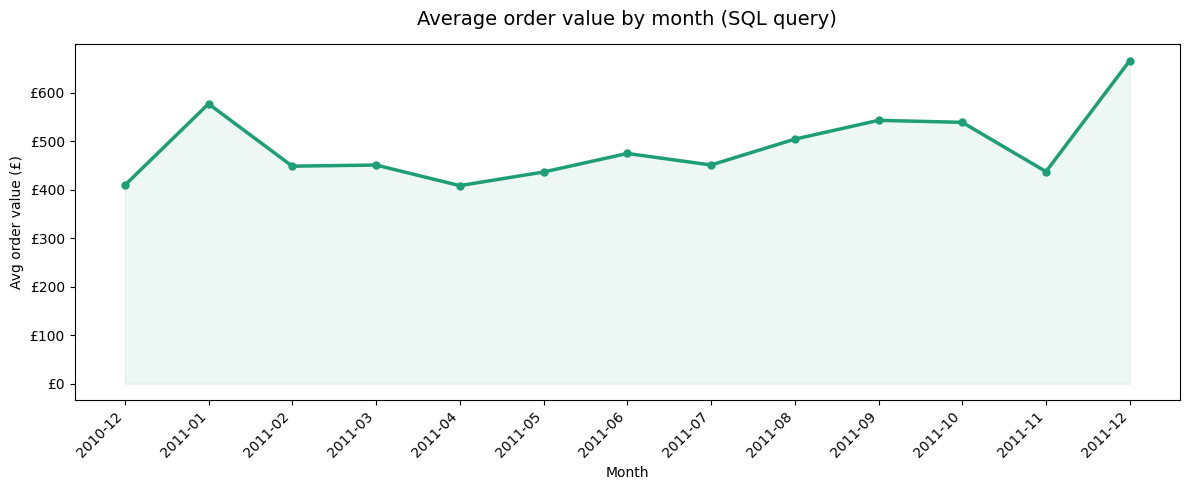

Chart saved!


In [7]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(aov['YearMonth'], aov['Avg_Order_Value'],
        color='#1D9E75', linewidth=2.5, marker='o', markersize=5)
ax.fill_between(aov['YearMonth'], aov['Avg_Order_Value'],
                alpha=0.08, color='#1D9E75')

ax.set_title('Average order value by month (SQL query)', fontsize=14, pad=14)
ax.set_xlabel('Month')
ax.set_ylabel('Avg order value (£)')
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../outputs/charts/avg_order_value.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

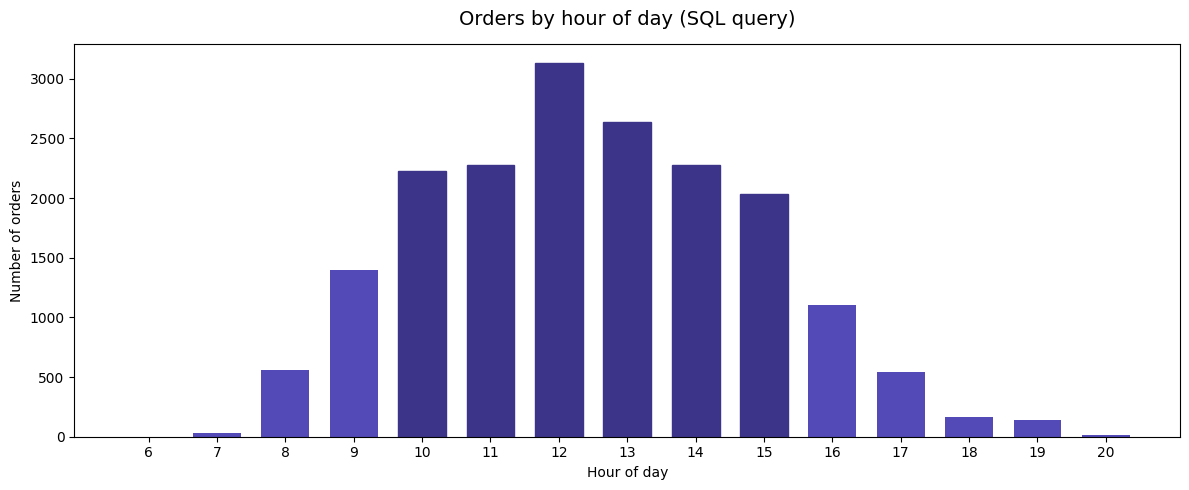

Chart saved!


In [8]:
fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.bar(hours['Hour'], hours['Total_Orders'],
              color='#534AB7', edgecolor='none', width=0.7)

# Highlight peak hours 10-15
for i, bar in enumerate(bars):
    hour = hours.iloc[i]['Hour']
    if 10 <= hour <= 15:
        bar.set_color('#3C3489')

ax.set_title('Orders by hour of day (SQL query)', fontsize=14, pad=14)
ax.set_xlabel('Hour of day')
ax.set_ylabel('Number of orders')
ax.set_xticks(hours['Hour'])
plt.tight_layout()
plt.savefig('../outputs/charts/orders_by_hour.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [9]:
# Key SQL findings
best_aov_month = aov.loc[aov['Avg_Order_Value'].idxmax()]
peak_hour = hours.loc[hours['Total_Orders'].idxmax()]
top_customer = pd.read_sql("""
    SELECT CAST(CustomerID AS INTEGER) as CustomerID,
           Country,
           ROUND(SUM(Revenue),2) as Revenue
    FROM sales
    GROUP BY CustomerID
    ORDER BY Revenue DESC LIMIT 1
""", conn)

print("=" * 55)
print("KEY FINDINGS — SQL ANALYSIS")
print("=" * 55)
print(f"Peak AOV month:      {best_aov_month['YearMonth']} (£{best_aov_month['Avg_Order_Value']:,.2f})")
print(f"Peak hour:           {int(peak_hour['Hour'])}:00 ({int(peak_hour['Total_Orders']):,} orders)")
print(f"Top customer ID:     {int(top_customer.iloc[0]['CustomerID'])}")
print(f"Top customer spend:  £{top_customer.iloc[0]['Revenue']:,.2f}")
print(f"Top customer country:{top_customer.iloc[0]['Country']}")
print("=" * 55)

# Always close the database connection when done
conn.close()
print("\nDatabase connection closed.")

KEY FINDINGS — SQL ANALYSIS
Peak AOV month:      2011-12 (£666.06)
Peak hour:           12:00 (3,130 orders)
Top customer ID:     14646
Top customer spend:  £280,206.02
Top customer country:Netherlands

Database connection closed.
